# **Mission 3 - Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [1]:
#Task 1
import pandas as pd


import pandas as pd

df_sales = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer_1.xlsx", sheet_name= 'sales')

df_invoice = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer_1.xlsx", sheet_name= 'invoice')

df_product = pd.read_excel(f"{notebookutils.nbResPath}/builtin/online_sales_retailer_1.xlsx", sheet_name= 'product')


# Display the first few rows of each DataFrame
display(df_sales.head())
display(df_invoice.head())
display(df_product.head())

In [2]:
import pandas as pd
from notebookutils import nbResPath

file_path = f"{nbResPath}/builtin/online_sales_retailer_1.xlsx"

xl = pd.ExcelFile(file_path)
print("Sheet names pandas sees:", xl.sheet_names)

Sheet names pandas sees: ['sales', 'invoice', 'product', 'December_Sales']


### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Create the Sales Column (Quantity * Unit Price) 

2. Check for missing values in the Sales DataFrame.

3. Replace any NaN values in the Sales and UnitPrice columns with 0.

4. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [3]:
#Task 2
#Create Sales column
df_sales['Sales'] = df_sales['Quantity'] * df_sales['UnitPrice']

display(df_sales.head(10))


In [4]:
print(df_sales.columns.tolist())

['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'InvoiceDate', 'Sales']


In [18]:
if 'sales' in df_sales.columns:
    df_sales = df_sales.drop(columns=['sales'])

StatementMeta(, 9a6e686d-d32f-4515-8397-450e6a7ad34d, 142, Finished, Available, Finished, False)

In [4]:
#Check for missing values
missing_values = df_sales.isnull()

#Display only rows with null values
rows_with_nulls = df_sales[missing_values.any(axis=1)]

#Display the rows with null values
display(rows_with_nulls)

In [5]:
print("df_sales missing:", df_sales.isnull().sum().sum())
print("df_invoice missing:", df_invoice.isnull().sum().sum())
print("df_product missing:", df_product.isnull().sum().sum())

df_sales missing: 0
df_invoice missing: 0
df_product missing: 0


In [6]:
#Descriptive statistics for 'Quantity', 'UnitPrice'
df_sales[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,83277.000000,83277.000000
mean,13.610961,3.083503
std,261.577565,5.177653
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,74215.000000,295.000000


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [7]:
#Task 3
# Merge Sales and Invoice DataFrames on 'InvoiceNo'
df_combined = pd.merge(df_sales, df_invoice, on='InvoiceNo')

# Display the first few rows of the merged DataFrame
display(df_combined.head())

**Here I used a left join when merging df_combined with df_product on 'StockCode' because I wanted to keep all rows from df_combined to retain all data including possible mismatches.**

In [10]:
#Merge df_combined with df_product on 'StockCode'
df_final = pd.merge(df_combined, df_product, on='StockCode', how='left')

#Display the first few rows of the final merged DataFrame
display(df_final.head())

In [11]:
display(df_final)

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [10]:
#Task 4
#Use describe to calculate summary stats for numeric columns (ie; Quantity and Sales).
df_final[['Quantity', 'UnitPrice', 'Sales']].describe()

,Quantity,UnitPrice,Sales
count,83277.000000,83277.000000,83277.000000
mean,13.610961,3.083503,23.121043
std,261.577565,5.177653,278.041319
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,5.000000
50%,6.000000,1.950000,12.500000
75%,12.000000,3.750000,19.500000
max,74215.000000,295.000000,77183.600000


**I chose to import matplotlib at this point as then we can use it to plot the results after filtering.**

In [12]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#Perform basic filtering, such as filtering out sales with Quantity equal to 0.
df_filtered = df_final[df_final['Quantity'] > 0]
display(df_filtered)



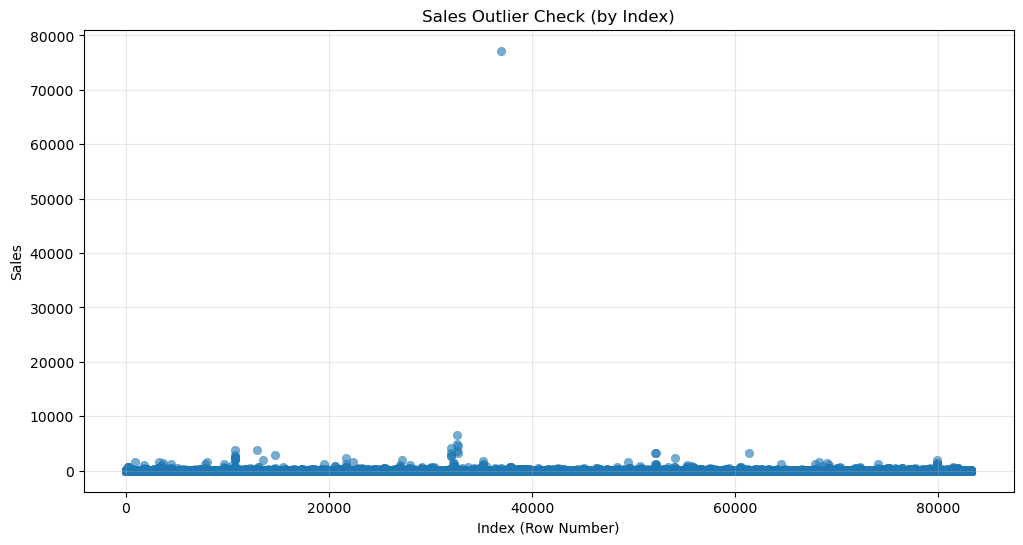

In [14]:
# Check for outliers in Sales column, using a scatterplot
plt.figure(figsize=(12, 6))

# Use the index on the x-axis
sns.scatterplot(x=df_filtered.index, y=df_filtered['Sales'], alpha=0.6, edgecolor=None)

plt.title('Sales Outlier Check (by Index)')
plt.xlabel('Index (Row Number)')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

In [38]:
# Task 5
# Check accuracy of 'UnitPrice' by creating new col- 'Unit_Price'
df_filtered['Unit_Price'] = df_filtered['Sales'] / df_filtered['Quantity']
display(df_filtered)

**To explore the relationship between Quantity and Sales I used the code below to uncover the correlation between the Sales and the Quantity. The correlation result was 0.978 (2dp) which initially seems to be a perfect score (as the quantity increases so does the sales in a consistent and predictable manner), however on closer inspection it is noticed that there is an outlier (with approximately 75K Quantity, and 77K Sales) that is skewing the results.**

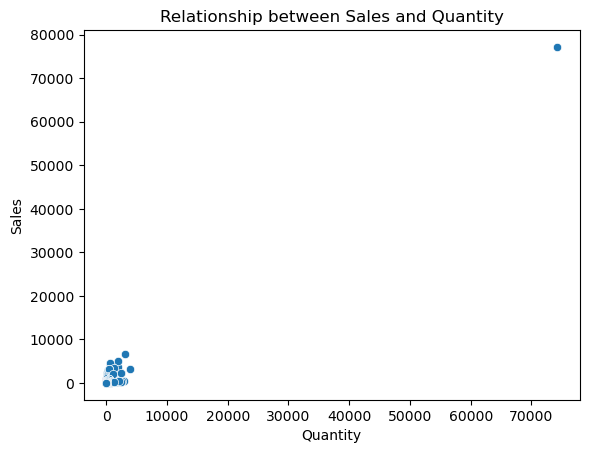

Correlation: 0.9786092498011646


In [39]:
# Scatterplot to show Relationship between Quantity & Sales 
sns.scatterplot(data=df_filtered, x='Quantity', y='Sales')
plt.title('Relationship between Sales and Quantity')
plt.show()

# Calculate the Correlation
correlation = df_filtered['Sales'].corr(df_filtered['Quantity'])
print(f"Correlation: {correlation}")

**For the Histogram to visualise the distribution of the Sales column, I applied the same filtering of sales < 10K to exclude the outlier to provide more accurate results. The histogram (below) shows a 'Right-Skewed' Distribution aka a 'Positive Skew', meaning that most of the sales are small, the insight is that the business is driven by a massive volume of lower value orders.**

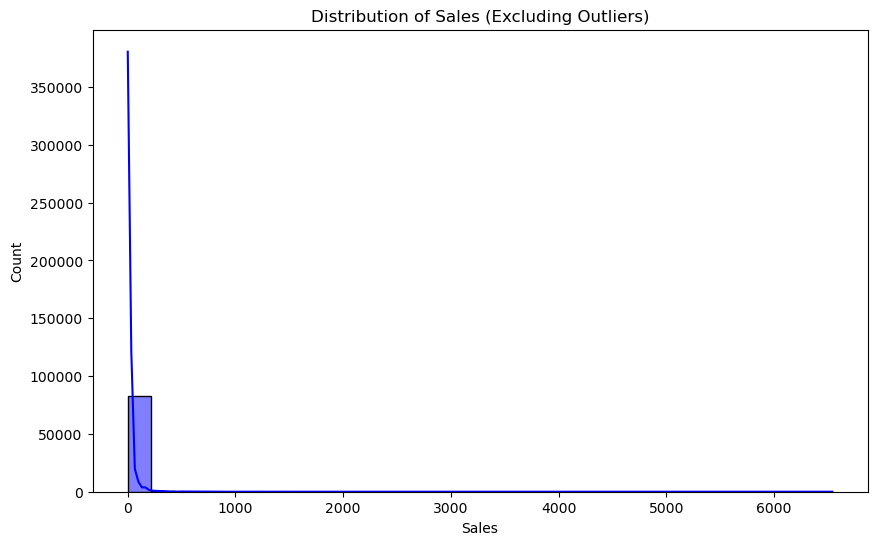

In [19]:
# Histogram to visualise the distribution of Sales column
# Filtering to see sales < 10K 
typical_sales = df_filtered[df_filtered['Sales'] < 10000]

plt.figure(figsize=(10, 6))
sns.histplot(typical_sales['Sales'], bins=30, kde=True, color='blue')
plt.title('Distribution of Sales (Excluding Outliers)')
plt.show()

**For the line chart I decided to group by 'Month' as there are close to 400K rows and the daily data will be messy to try to read. Insights from this line graph are that the busiest year from this time period (2015-2018), was easily 2016, which included the highest sales of approx 77K in July and the highest over all with approx 110K around December. July also proved to be fruitful in 2015 with the 3rd highest sales at just under 60K.** 

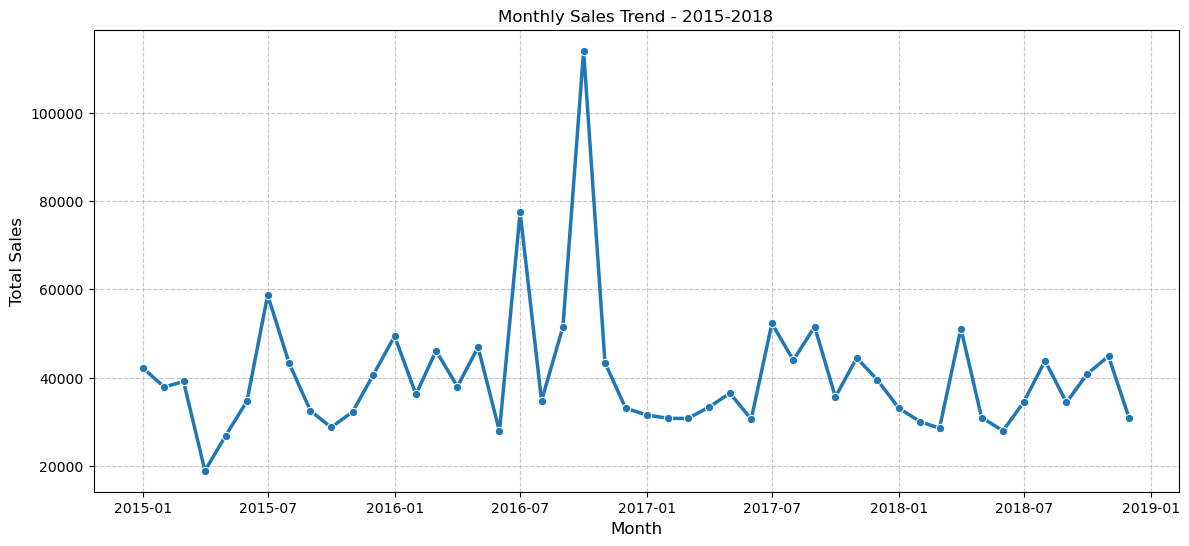

In [22]:
# A line chart to show the trend of Sales over time
# Convert 'InvoiceDate' to a datetime object
df_filtered['InvoiceDate'] = pd.to_datetime(df_filtered['InvoiceDate'])

# Group by Month and sum the Sales
#'MS'= Month Start - this puts the data point at the 1st of each month
monthly_trend = df_filtered.resample('MS', on='InvoiceDate')['Sales'].sum().reset_index()

# Create the Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend, x='InvoiceDate', y='Sales', marker='o', linewidth=2.5)

plt.title('Monthly Sales Trend - 2015-2018', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [20]:
print(df_filtered['InvoiceDate'].dt.year.unique())

[2015 2016 2017 2018]


## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

**In order to further explore the correlation of Quantity and Sales with out the outlier, it is necessary to exclude it to gain more accurate incite. In the code below a df is created where the Quantity is limited to < 10K. This generates a correlation of 0.66 (2dp), which is considered 'Strong', where most units follow a pricing trend, with the caveat that there maybe different pricing structures or bulk discounts for example that effect the total that could be explored futher with future research being done on addtional data like COG's and Profit not in this dataset.**

Correlation without the outlier: 0.6611192343666927


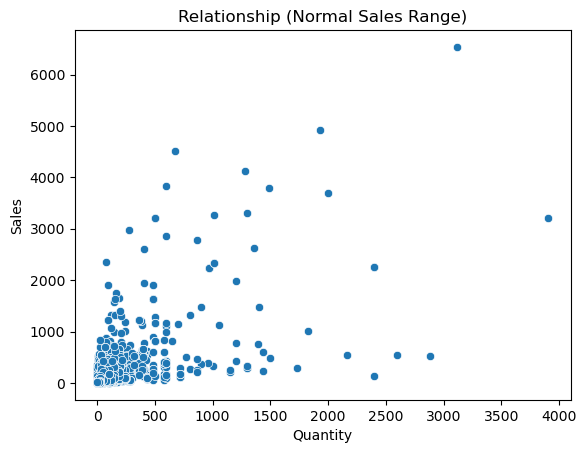

In [23]:
# Task 6
# Calculate the correlation between Quantity and Sales.
# Create a df without the massive outlier
df_normal = df_filtered[df_filtered['Quantity'] < 10000]

# Re-run correlation
new_corr = df_normal['Sales'].corr(df_normal['Quantity'])
print(f"Correlation without the outlier: {new_corr}")

# New Scatterplot
sns.scatterplot(data=df_normal, x='Quantity', y='Sales')
plt.title('Relationship (Normal Sales Range)')
plt.show()

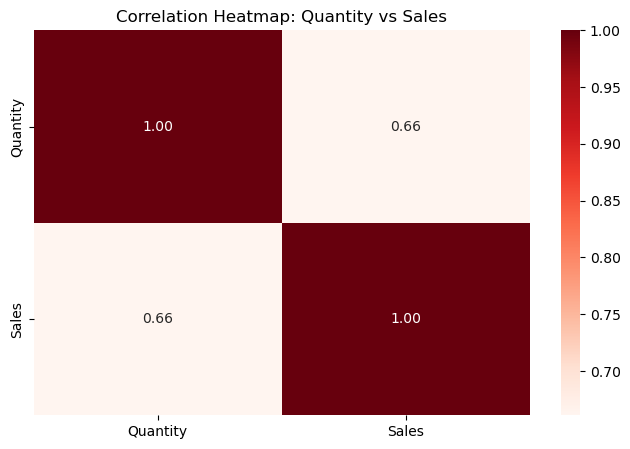

In [25]:
#Visualise the correlation matrix using a heatmap.
to_correlate = df_normal[['Quantity', 'Sales']]

# Create the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(to_correlate.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Heatmap: Quantity vs Sales')
plt.show()

**In conclusion, although it initially appeared that the correlation between Quantity and Sales was strong 0.98, this was found to be skewed by an outlier, and after removing this outlier, it was found to be 0.66 which is moderate strength. This value of 0.66 suggests that while higher quantities generally lead to higher sales there is significant variation in the data, probably due to a range of products sold and different price points or promotions.** 

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [32]:
#Task 7
# GroupBy operation: Group by Product_Category and calculate the total Sales per category.
# Group by Product_Category, sum the Sales
category_sales = df_filtered.groupby('Product_Category')['Sales'].sum().reset_index()

# Sort the results from highest to lowest sales
category_sales = category_sales.sort_values(by='Sales', ascending=False)

# Display the result
display(category_sales)

**In this Group by output (above) we can clearly see that the highest category is 'Uncategorized' at 191K, in other words approx 1/3 of the total revenue is coming from items that are not categorised, this is useful information for making business decisions and maximising your profit, recommend fixing this asap. Christmas products comes in at 2nd highest with 88K, which shows a seasonal trend common in retail.** 

In [35]:
# Create Pivot Table to show Sales by Country and Product_Category
# fill_value=0 turns 'NaN' (empty cells) into 0
pivot_sales = df_filtered.pivot_table(index='Country', columns='Product_Category', values='Sales', aggfunc='sum', fill_value=0)

print(pivot_sales.iloc[:10, :5]) 

Product_Category  APRON  BACKPACK  BADGES     BAG  BALLOONS
Country                                                    
AUS                0.00       0.0    0.00   15.60      0.00
Australia          0.00       0.0    0.00  188.56     10.08
Austria            0.00       0.0    0.00   58.18      0.00
Bahrain            0.00       0.0    0.00    0.00      0.00
Belgium           45.27       0.0   17.85  206.74      0.00
Brazil             0.00       0.0    0.00    0.00      0.00
Canada             0.00       0.0    0.00    0.00      0.00
Channel Islands    5.04       0.0    0.00   80.75      5.95
Cyprus             0.00       0.0    0.00    0.00      0.00
Czech Republic     0.00       0.0    0.00    0.00      0.00


**I added some sorting (below) to the pivot table as pandas lists countries alphabetically which is not helpful for analysis.**

In [36]:
# Create the pivot table
pivot_sales = df_filtered.pivot_table(index='Country', columns='Product_Category', values='Sales', aggfunc='sum', fill_value=0)

# Adding a total column so we know which has largest sales
pivot_sales['Grand_Total'] = pivot_sales.sum(axis=1)

# Sort by highest total
pivot_sales = pivot_sales.sort_values(by='Grand_Total', ascending=False)

# Top 10 countries, First 5 categories
print(pivot_sales.iloc[:10, :5])

Product_Category    APRON  BACKPACK   BADGES       BAG  BALLOONS
Country                                                         
United Kingdom    3704.45      97.3  2041.98  41902.38    265.97
Germany              1.67       0.0    15.00    830.03      0.00
France               4.95       0.0     1.68    548.40      0.00
New Zealand         22.30       0.0    86.64   1204.77      5.04
Belgium             45.27       0.0    17.85    206.74      0.00
Netherlands         14.90       0.0     0.00    216.84      5.04
Spain               15.00       0.0     0.00     52.16      0.00
Australia            0.00       0.0     0.00    188.56     10.08
Poland               0.00       0.0   252.00     28.45      0.00
Portugal             4.95       0.0     0.00     56.28      0.00


## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Good work